In [ ]:
import pandas as pd

# Cargar archivo
file_path = '/content/Datos_Consolidados_reckitt_2025.xlsx'

# Leer hojas
dim_date = pd.read_excel(file_path, sheet_name='DIM_DATE')
dim_category = pd.read_excel(file_path, sheet_name='DIM_CATEGORY')
fact_sales = pd.read_excel(file_path, sheet_name='FACT_SALES')
dim_segment = pd.read_excel(file_path, sheet_name='DIM_SEGMENT')
dim_product = pd.read_excel(file_path, sheet_name='DIM_PRODUCT')


fact_sales.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


In [ ]:
# Join
# Merge con producto
df = fact_sales.merge(dim_product, left_on='ITEM_CODE', right_on='ITEM', how='left')

# Merge con categoría
df = df.merge(dim_category, left_on='CATEGORY', right_on='ID_CATEGORY', how='left')

# Merge con fechas
df = df.merge(dim_date, on='WEEK', how='left')

df.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,...,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT AND SANIT,2022,8,34,2022/08/28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022/08/28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022/08/28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022/08/28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022/08/28


In [ ]:
# Limpieza
# Convertir fecha
df['DATE'] = pd.to_datetime(df['DATE'])

# Eliminar nulos
df = df.dropna()

# Eliminar duplicados
df = df.drop_duplicates()

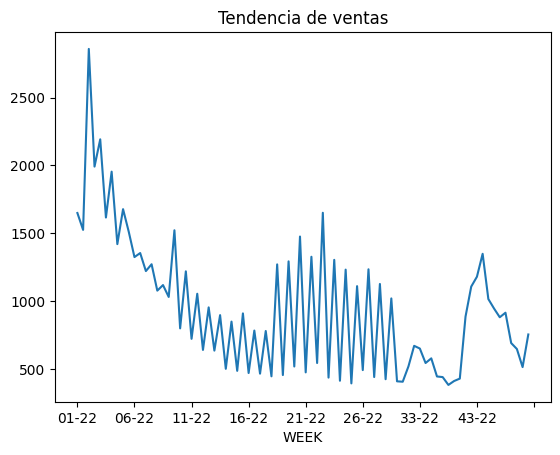

In [ ]:
# EDA
# Ventas en el tiempo
import matplotlib.pyplot as plt

ventas_tiempo = df.groupby('WEEK')['TOTAL_VALUE_SALES'].sum()

ventas_tiempo.plot()
plt.title('Tendencia de ventas')
plt.show()

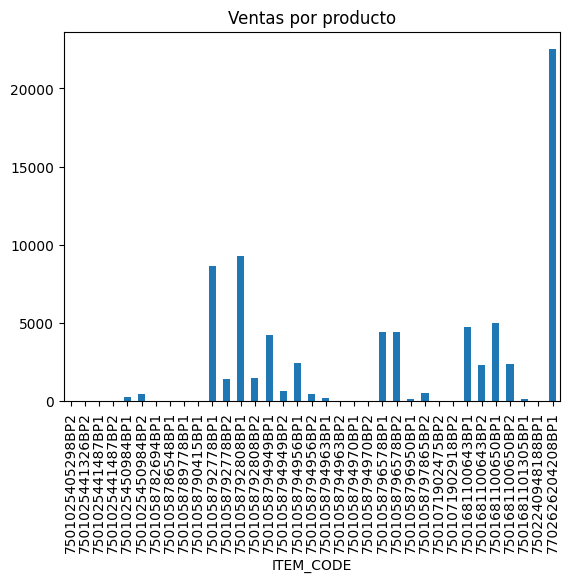

In [ ]:
# Ventas por producto
ventas_categoria = df.groupby('ITEM_CODE')['TOTAL_VALUE_SALES'].sum()

ventas_categoria.plot(kind='bar')
plt.title('Ventas por producto')
plt.show()

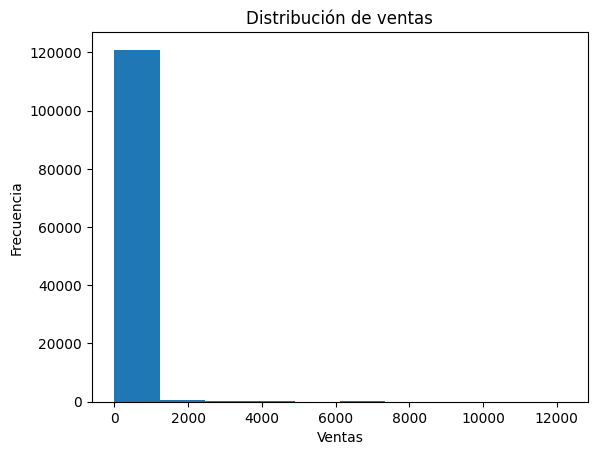

In [ ]:
# Distribución
import matplotlib.pyplot as plt

plt.hist(fact_sales['TOTAL_VALUE_SALES'])
plt.title('Distribución de ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.show()

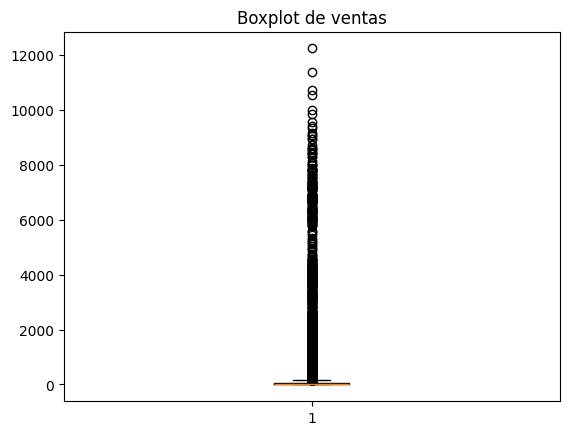

In [ ]:
# Boxplot
plt.boxplot(fact_sales['TOTAL_VALUE_SALES'])
plt.title('Boxplot de ventas')
plt.show()

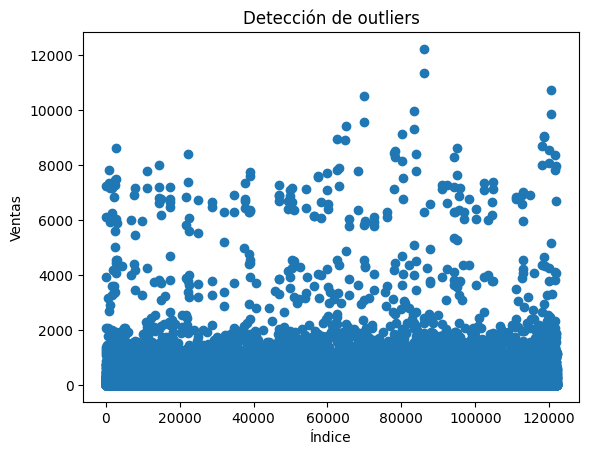

In [ ]:
plt.scatter(fact_sales.index, fact_sales['TOTAL_VALUE_SALES'])
plt.title('Detección de outliers')
plt.xlabel('Índice')
plt.ylabel('Ventas')
plt.show()

# Machine Learning

In [ ]:
ts['WEEK'].head(10)

,WEEK
0,01-22
1,01-23
2,02-22
3,02-23
4,03-22
5,03-23
6,04-22
7,04-23
8,05-22
9,05-23


In [ ]:
# Preparar datos - ordenar fechas
ts = ts.sort_values('WEEK')

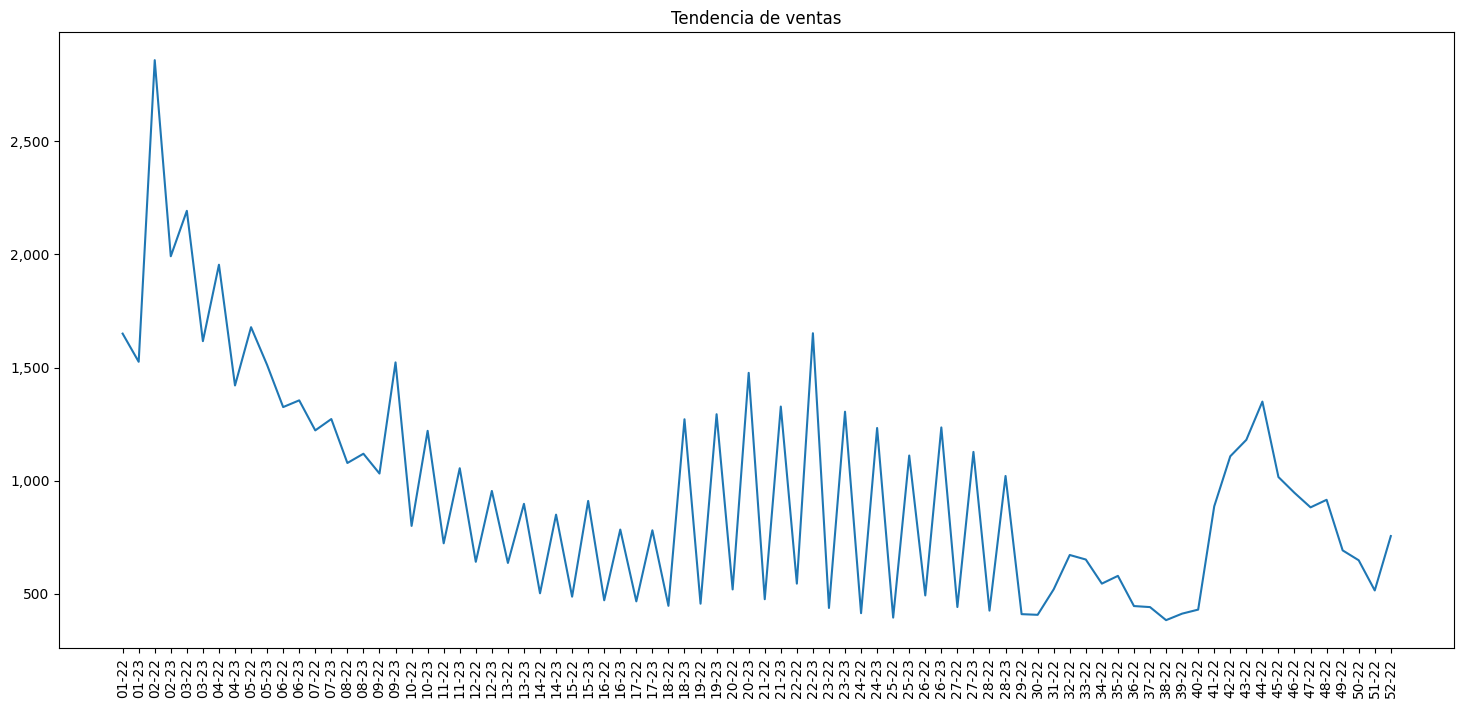

In [ ]:
# Gráfica
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(18,8))

plt.plot(ts['WEEK'], ts['TOTAL_VALUE_SALES'])

plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Tendencia de ventas')
plt.show()

In [ ]:
# Modelo - regresión lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(ts[['t']], ts['TOTAL_VALUE_SALES'])

ts['pred'] = model.predict(ts[['t']])

KeyError: "None of [Index(['t'], dtype='object')] are in the [columns]"

In [ ]:
# Preparar datos
ts = df.groupby('WEEK')['TOTAL_VALUE_SALES'].sum().reset_index()
ts = ts.sort_values('WEEK')

In [ ]:
import numpy as np

ts['t'] = np.arange(len(ts))

In [ ]:
# Verifico
ts.head()

,WEEK,TOTAL_VALUE_SALES,t
0,01-22,1649.798,0
1,01-23,1525.283,1
2,02-22,2858.308,2
3,02-23,1991.615,3
4,03-22,2192.402,4


In [ ]:
# Modelo regresión lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(ts[['t']], ts['TOTAL_VALUE_SALES'])

ts['pred'] = model.predict(ts[['t']])

In [ ]:
# Variables
ts['mes'] = ts['WEEK'].astype(str).str[:2]   # sformato tipo 01-22
ts['mes'] = ts['mes'].astype(int)

In [ ]:
# Modelo múltiple
from sklearn.linear_model import LinearRegression

X = ts[['t', 'mes']]
y = ts['TOTAL_VALUE_SALES']

model_multi = LinearRegression()
model_multi.fit(X, y)

ts['pred_multi'] = model_multi.predict(X)

In [ ]:
# Validación
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_multi = mean_absolute_error(y, ts['pred_multi'])
mse_multi = mean_squared_error(y, ts['pred_multi'])

mae_multi, mse_multi

(307.23472659120455, 146124.79098919436)

In [ ]:
# Preddición
future_t = np.arange(len(ts), len(ts)+12)
future_mes = future_t % 12

future_df = pd.DataFrame({
    't': future_t,
    'mes': future_mes
})

future_df['pred'] = model_multi.predict(future_df)
future_df

,t,mes,pred
0,80,8,-2006.279429
1,81,9,-1992.963946
2,82,10,-1979.648464
3,83,11,-1966.332982
4,84,0,-2719.538890
5,85,1,-2706.223408
6,86,2,-2692.907926
7,87,3,-2679.592443
8,88,4,-2666.276961
9,89,5,-2652.961479
